# 2.3 - Modeling - Testing

In this step, the best performing model obtained in the file **2.2 - Modeling_FineTunning.ipynb** will be used to make predictions on the test set. The main performance metrics will be evaluated and an analysis of the possible financial gains associated with the implementation of the model in fraud detection will be carried out.

## Importing Libs

In [35]:
# Importing Libs
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", rc={'figure.figsize':(10,6)})

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, precision_score, recall_score, precision_recall_curve, ConfusionMatrixDisplay, roc_curve


from xgboost import XGBClassifier

import joblib
import warnings

## Importing Dataset and Feature Engeneering

In this step:
- The dataset was imported
- The values created in section **1 - EDA.ipynb**, `balanceOrigDiff` and `balanceDestDiff` were used
- Values that would not be relevant in the forecast were removed

In [4]:
FRAUD_PATH = "datasets/AIML Dataset.csv"

df = pd.read_csv(FRAUD_PATH)

categorical_features = ['type', 'nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
numerical_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

df['balanceOrigDiff'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balanceDestDiff'] = df['newbalanceDest'] - df['oldbalanceDest']

features_model = numerical_features + ['balanceOrigDiff', 'balanceDestDiff', 'isFraud']
df_model = df[features_model]

df_model.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceOrigDiff,balanceDestDiff,isFraud
0,1,9839.64,170136.0,160296.36,0.0,0.0,-9839.64,0.0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,-1864.28,0.0,0
2,1,181.00,181.0,0.00,0.0,0.0,-181.00,0.0,1
3,1,181.00,181.0,0.00,21182.0,0.0,-181.00,-21182.0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,-11668.14,0.0,0


## Train Test Split

The data was divided as follows:
- The class of interest (`isFraud`) was separated as **y** and the others as **X**
- The division was made in a 70-30 ratio due to the high volume of data
- The `stratify` hyperparameter was used in order to maintain the proportion of positive and negative classes for both the test set and the training set
- Since there are no categorical values, it was only necessary to make the `StandardScaler`

In [7]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state = 42)

In [9]:
scaler =  StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

`StratifiedKFold` is used to divide the data into K parts (folds) to perform cross-validation, maintaining the proportion of classes in each fold.
In other words, in each Cross-Validation it is guaranteed that each fold has representation of the classes.

In [11]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Testing

In [13]:
MODEL_EVALUATION_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "precision",
    "recall",
    "roc_auc",
    "average_precision",
    "neg_brier_score",
    "f1_weighted",
]

In [14]:
filename = 'best_xgb_model.joblib'
xgbclf = joblib.load(filename)

In [15]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    
    scores = cross_validate(estimator = xgbclf, X = X_train_scaled, y = y_train, cv=stratified_kfold, scoring=MODEL_EVALUATION_METRICS)

In [16]:
def score_to_df(score, sum_time):
    """
    Convert values of scores from cross validation to DataFrame.

    Parameters
    ----------
    score : dict
        Dictionary with respective scores from cross validation.

    sum_time : bool
        Select if the user want to have the sum of the fit and score time or not.

    Returns
    -------
    pd.DataFrame
        DataFrame with cross validation results.
    """

    df = pd.DataFrame(score)
    

    if sum_time:
        df['total_time'] = df['fit_time'] + df['score_time']
        df = df.drop(columns=['fit_time', 'score_time'])

    df = df.T

    mean_series = df.mean(axis=1)

    return(df, mean_series)
df_test, mean_series = score_to_df(score = scores, sum_time = True)
df_test

,0,1,2,3,4
test_accuracy,0.999689,0.999679,0.999695,0.999696,0.999656
test_balanced_accuracy,0.910395,0.907784,0.911700,0.908227,0.899001
test_f1,0.872055,0.867715,0.874423,0.873895,0.857009
test_precision,0.930049,0.926877,0.932087,0.939940,0.925328
test_recall,0.820870,0.815652,0.823478,0.816522,0.798085
test_roc_auc,0.999312,0.999355,0.998619,0.999622,0.999528
test_average_precision,0.942226,0.937469,0.938549,0.938762,0.931821
test_neg_brier_score,-0.000241,-0.000254,-0.000241,-0.000248,-0.000271
test_f1_weighted,0.999679,0.999669,0.999685,0.999685,0.999644
total_time,67.708119,67.531903,64.079939,64.189501,64.633201


In [17]:
mean_series

test_accuracy              0.999683
test_balanced_accuracy     0.907422
test_f1                    0.869020
test_precision             0.930856
test_recall                0.814921
test_roc_auc               0.999287
test_average_precision     0.937765
test_neg_brier_score      -0.000251
test_f1_weighted           0.999672
total_time                65.628533
dtype: float64

In [18]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    y_proba = cross_val_predict(estimator = xgbclf, X = X_train_scaled, y = y_train, cv=stratified_kfold, method="predict_proba")

## Precision and Recall Analysis

In [69]:
precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba[:, 1])

print("Precision: {}".format(precisions))
print("Recall: {}".format(recalls))
print("Threshold: {}".format(thresholds))

Precision: [0.0012908 0.0012908 0.0012908 ... 1.        1.        1.       ]
Recall: [1.         1.         1.         ... 0.00417464 0.00260915 0.        ]
Threshold: [2.2565717e-11 2.3723754e-11 2.5062152e-11 ... 9.9999964e-01 9.9999976e-01
 9.9999988e-01]


In [70]:
def precision_and_recall_scores_plot(threshold, precision, recall, mean_prec, mean_rec):
    """
    Obs: if you have used precision_recall_curve, you'll need to set the values of recall and precision with [:-1]. ex: precisions[:-1]

    Plot Scores from Precision and Recall × Threshold.

    Parameters
    ----------
    threshold : array
        Threshold from the precision_recall_curve.

    precision : array
        Precision from the precision_recall_curve.

    recall : array
        Recall from the precision_recall_curve.

    mean_prec: float
        Mean Precision from the model.
        
    mean_rec: float
        Mean Recall from the model.

    Returns
    -------
    Graph
        Scores from Precision and Recall × Threshold and current threshold.
    """

    # 4. Encontrar o ponto mais próximo (menor distância euclidiana)
    distances = np.sqrt((precision - mean_prec)**2 + (recall - mean_rec)**2)
    best_threshold_idx = np.argmin(distances)
    best_threshold = threshold[best_threshold_idx]
    
    # 5. Plotar o gráfico com marcação do threshold
    plt.figure(figsize=(10, 6))
    plt.plot(threshold, precision, label="Precision", color="blue")
    plt.plot(threshold, recall, label="Recall", color="green")
    
    # Linha vertical no melhor threshold
    plt.axvline(best_threshold, color="red", linestyle="--", label=f"Threshold ≈ {best_threshold:.3f}")
    
    # Ponto destacado no gráfico
    plt.scatter(threshold[best_threshold_idx], precision[best_threshold_idx], color="blue", marker='o')
    plt.scatter(threshold[best_threshold_idx], recall[best_threshold_idx], color="green", marker='o')
    
    plt.title("Precision and Recall vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend(loc="lower center", fontsize=13)
    plt.grid(True)
    plt.show()

    return(None)

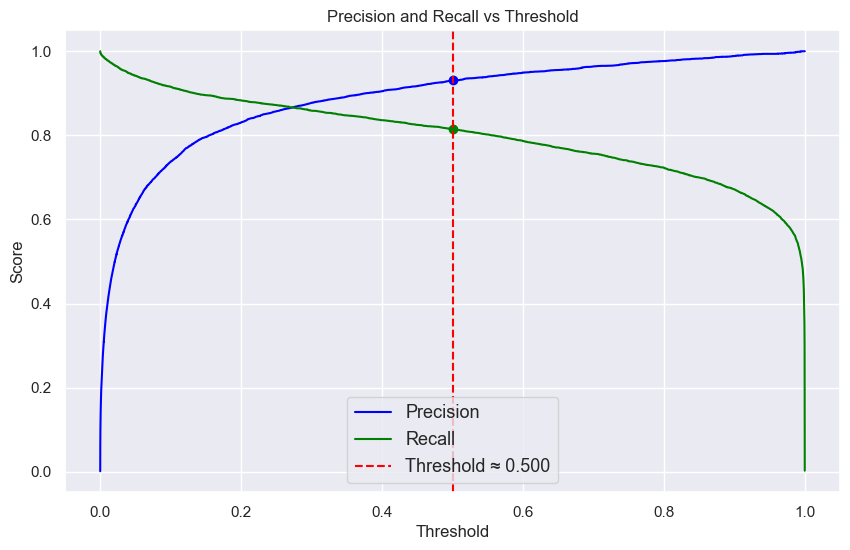

In [71]:
precision_and_recall_scores_plot(threshold = thresholds, 
                                 precision = precisions[:-1], 
                                 recall = recalls[:-1], 
                                 mean_prec = mean_series["test_precision"], 
                                 mean_rec = mean_series["test_recall"])

## Precision × Recall

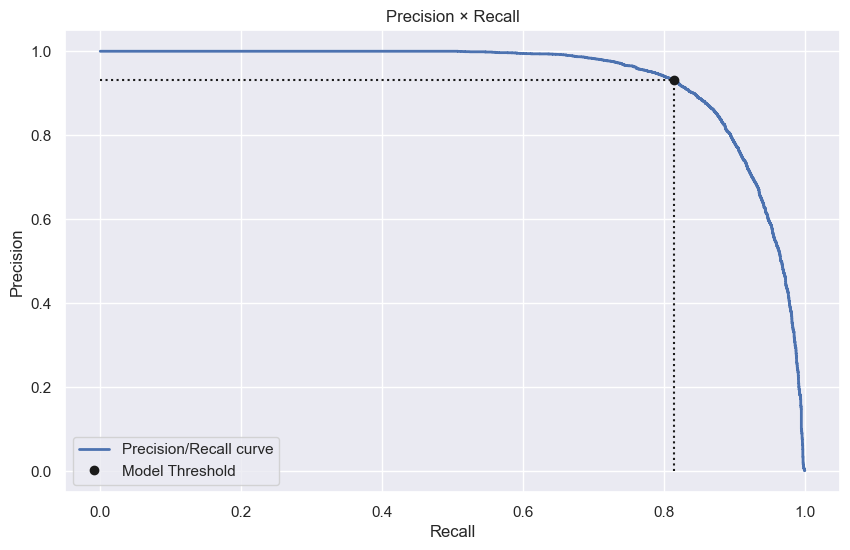

In [75]:
def precision_recall_curve(precision, recall, mean_prec, mean_rec):
    """
    Plot Precision × Recall curve.

    Parameters
    ----------
    precision : array
        Precision from the precision_recall_curve.

    recall : array
        Recall from the precision_recall_curve.

    mean_prec: float
        Mean Precision from the model.
        
    mean_rec: float
        Mean Recall from the model.

    Returns
    -------
    Graph
        Precision × Recall curve and current threshold.
    """

    distances = np.sqrt((precision - mean_prec)**2 + (recall - mean_rec)**2)
    best_idx = np.argmin(distances)

    
    plt.figure(figsize=(10, 6))

    plt.plot(recall, precision, linewidth=2, label="Precision/Recall curve")


    plt.plot([recall[best_idx], recall[best_idx]], [0., precision[best_idx]], "k:") # vertical dotted line
    plt.plot([0.0, recall[best_idx]], [precision[best_idx], precision[best_idx]], "k:") # horizontal dotted line
    plt.plot([recall[best_idx]], [precision[best_idx]], "ko", label="Model Threshold")


    
    plt.title("Precision × Recall")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    
    plt.show()
    
    return(None)
    
precision_recall_curve(precisions, recalls, mean_prec = mean_series["test_precision"], mean_rec = mean_series["test_recall"])

## ROC

In [77]:
fpr, tpr, threshold_ROC = roc_curve(y_train, y_proba[:, 1])

print("FPR: {}".format(fpr))
print("TPR: {}".format(tpr))
print("Threshold: {}".format(threshold_ROC))

FPR: [0.         0.         0.         ... 0.9999438  0.99994425 1.        ]
TPR: [0.         0.00260915 0.00417464 ... 1.         1.         1.        ]
Threshold: [          inf 9.9999988e-01 9.9999976e-01 ... 7.5147139e-11 7.5036137e-11
 2.2565717e-11]


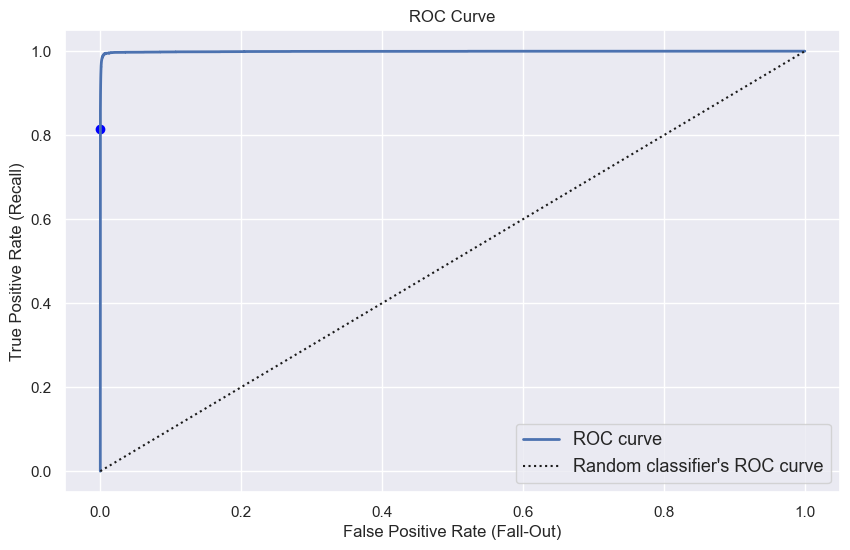

In [79]:
def plot_roc_curve(FPR, TPR, mean_tpr):
    """
    Plot ROC curve.

    Parameters
    ----------
    FPR : array
        False Positive Rate from the roc_curve.

    TPR : array
        True Positive Rate from the roc_curve.

    mean_tpr: float
        Mean True Positive Rate (Mean Recall) to observe the position of the model.

    Returns
    -------
    Graph
        ROC Curve.
    """


    distances = np.sqrt((TPR - mean_tpr)**2)
    best_idx = np.argmin(distances)


    plt.figure(figsize=(10, 6))
    plt.plot(FPR, TPR, linewidth=2, label="ROC curve")
    plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

    plt.scatter(FPR[best_idx], TPR[best_idx], color="blue", marker='o')

    

    
    plt.title("ROC Curve")
    plt.xlabel('False Positive Rate (Fall-Out)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.legend(loc="lower right", fontsize=13)
    plt.grid(True)
    plt.show()
    return(None)

plot_roc_curve(fpr, tpr, mean_tpr = mean_series["test_recall"])

The last two functions of this section will be used in later tests to see the influence of recall on the number of fraudulent transactions, and will not be used at the moment:

In [82]:
def recall_for_precision(y_train, y_prob, threshold, n_prec, precision):
    """
    Get the values of recall and threshold from a respective precision value.

    Parameters
    ----------
    y_train : pd.Series
        Targets of the training set.

    y_prob : pd.Series
        Predicted probablities from the model.

    threshold : pd.Series
        Obtained threshold values from precision_recall_curve.
        
    n_prec : float
        Chosen precision value.

    precision : pd.Series
        Obtained precision values from precision_recall_curve.

    Returns
    -------
    pd.DataFrame
        Threshold, Recall and Nearest Precision value obtained from precision_recall_curve.
    """

    idx_for_XX_precision = (precision >= n_prec).argmax()
    threshold_for_XX_precision = threshold[idx_for_XX_precision]

    print(f"The threshold for the precision {(n_prec*100):.3f} is: {threshold_for_XX_precision:.3f}")

    y_train_pred_XX = (y_prob >= threshold_for_XX_precision)
    nearest_precision = precision_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The nearest precision from {(n_prec*100):.3f} is: {(nearest_precision):.3f}")
    
    recall_at_XX_precision = recall_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The threshold for the precision {(n_prec*100):.3f} is: {(recall_at_XX_precision):.3f}")

    return(None)
    

In [83]:
recall_for_precision(y_train = y_train, 
                     y_prob = y_proba, 
                     threshold = thresholds, 
                     n_prec = 0.885, 
                     precision = precisions)    

The threshold for the precision 88.500 is: 0.324
The nearest precision from 88.500 is: 0.885
The threshold for the precision 88.500 is: 0.853


In [84]:
def precision_for_recall(y_train, y_prob, threshold, n_rec, recall):
    """
    Get the values of precision and threshold from a respective recall value.

    Parameters
    ----------
    y_train : pd.Series
        Targets of the training set.

    y_prob : pd.Series
        Predicted probablities from the model.

    threshold : pd.Series
        Obtained threshold values from precision_recall_curve.
        
    n_rec : float
        Chosen recall value.

    recall : pd.Series
        Obtained recall values from precision_recall_curve.

    Returns
    -------
    pd.DataFrame
        Threshold, Precision and Nearest Recall value obtained from precision_recall_curve.
    """

    idx_for_XX_recall = (recall >= n_rec).argmin()
    threshold_for_XX_recall = threshold[idx_for_XX_recall]

    print(f"The threshold for the recall {(n_rec*100):.3f} is: {threshold_for_XX_recall:.3f}")

    y_train_pred_XX = (y_prob >= threshold_for_XX_recall)
    nearest_recall = recall_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The nearest recall from {(n_rec*100):.3f} is: {(nearest_recall):.3f}")
    
    precision_at_XX_recall = precision_score(y_train, y_train_pred_XX[:,1])
    
    print(f"The precision for the recall {(n_rec*100):.3f} is: {(precision_at_XX_recall):.3f}")

    return(None)

In [86]:
precision_for_recall(y_train = y_train, 
                     y_prob = y_proba, 
                     threshold = thresholds, 
                     n_rec = 0.85337, 
                     recall = recalls)

The threshold for the recall 85.337 is: 0.322
The nearest recall from 85.337 is: 0.853
The precision for the recall 85.337 is: 0.884


## Model Analysis

Below will be performed the evaluations on the testing set in the acquired model

### Prediction

In [91]:
# Predicting values
y_pred = xgbclf.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998   1906322
           1     0.9250    0.8064    0.8617      2464

    accuracy                         0.9997   1908786
   macro avg     0.9624    0.9032    0.9307   1908786
weighted avg     0.9997    0.9997    0.9997   1908786



In [92]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1906161,     161],
       [    477,    1987]], dtype=int64)

### Confusion Matrix

In [96]:
def confusion_matrix_disp(true_y, pred_y, titles, norm = None):
    """
    Plot ROC curve.

    Parameters
    ----------
    true_y : array
        True target values from test set.

    pred_y : array
        Predicted values from test set.

    titles: str
        Graph Title.
        
    titles: bool
        Return the graph normalized with the percent values.

    Returns
    -------
    Graph
        Confusion Matrix.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ConfusionMatrixDisplay.from_predictions(y_true = true_y,
                                            y_pred = pred_y,
                                            ax = ax,
                                            normalize = norm, 
                                            cmap = "RdBu",
                                            im_kw = {"alpha": 0.75},
                                            text_kw = {"size": "large", "color": "white", "fontweight": "bold"},
                                           )

    fig.suptitle("Confusion Matrix for the Best Model")
    ax.set_title(titles)
    
    plt.grid(False)
    plt.show()


    return(None)

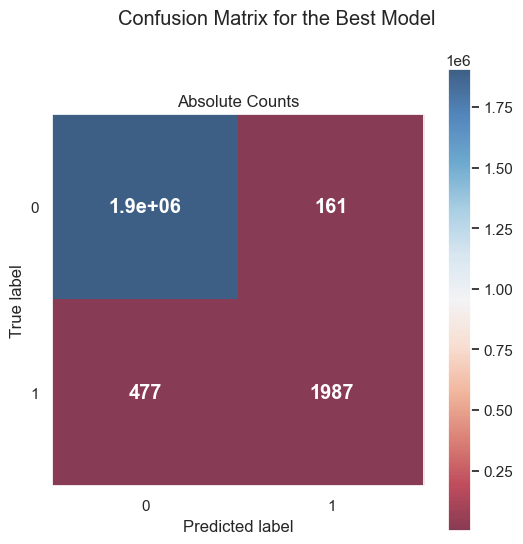

In [97]:
confusion_matrix_disp(true_y = y_test, pred_y = y_pred, titles = "Absolute Counts", norm = None)

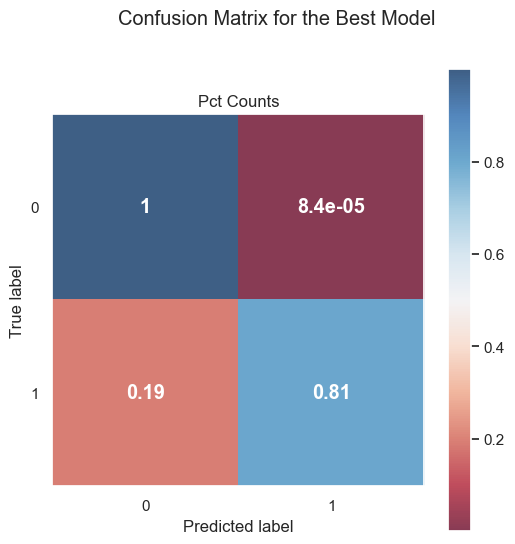

In [98]:
confusion_matrix_disp(true_y = y_test, pred_y = y_pred, titles = "Pct Counts", norm = "true")

### Financial Analysis

In this last evaluation session, we will estimate possible saved values ​​and financial expenses obtained from the trained model.

Below, the testing dataset was used, adding a column with predicted values for each instance. The column `actualFraud` represents the actual values, and `predictedFraud` the predicted values.

In [104]:
X_test_df = pd.DataFrame(X_test, columns=X.columns) 


X_test_df["actualFraud"] = y_test.values
X_test_df["predictedFraud"] = y_pred

In [105]:
X_test_df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceOrigDiff,balanceDestDiff,actualFraud,predictedFraud
1453282,140,6974.39,10503.00,3528.61,0.00,0.00,-6974.39,0.00,0,0
5338477,374,157690.96,16627.00,174317.96,73436.77,0.00,157690.96,-73436.77,0,0
2396500,201,17907.49,16282.06,0.00,0.00,0.00,-16282.06,0.00,0,0
4577381,328,22394.94,75530.38,53135.44,0.00,0.00,-22394.94,0.00,0,0
2922798,229,106631.35,0.00,0.00,2210314.37,2316945.72,0.00,106631.35,0,0
...,...,...,...,...,...,...,...,...,...,...
4396799,321,54325.41,24982.96,0.00,0.00,0.00,-24982.96,0.00,0,0
6263861,612,17968.03,10746.00,0.00,0.00,0.00,-10746.00,0.00,0,0
3051968,234,84564.51,0.00,0.00,90419.23,174983.74,0.00,84564.51,0,0
6184144,567,45590.73,383818.24,338227.51,1077781.53,1123372.26,-45590.73,45590.73,0,0


In [106]:
# Actual fraud amounts that were correctly detected (TP)
tp_value = X_test_df.query("actualFraud == 1 and predictedFraud == 1")["amount"].sum()

# Fraud amounts that went undetected (FN)
fn_value = X_test_df.query("actualFraud == 1 and predictedFraud == 0")["amount"].sum()

# Amounts that were falsely accused of fraud (FP)
fp_value = X_test_df.query("actualFraud == 0 and predictedFraud == 1")["amount"].sum()

# Legitimate amounts that were correctly classified (TN)
tn_value = X_test_df.query("actualFraud == 0 and predictedFraud == 0")["amount"].sum()

print(f"Total recovered for detected fraud (TP): ${tp_value:,.2f}")
print(f"Total lost due to undetected fraud (FN): ${fn_value:,.2f}")
print(f"Potential cost of false positives (FP): ${fp_value:,.2f}")
print(f"Legitimate transactions carried out (TN): $ {tn_value:,.2f}")

Total recovered for detected fraud (TP): $3,452,713,320.11
Total lost due to undetected fraud (FN): $67,536,969.82
Potential cost of false positives (FP): $47,577,078.78
Legitimate transactions carried out (TN): $ 339,403,439,224.48


Note: The graph below does not contain the values of legitimate transactions (TN) as this makes it difficult to view the other parameters given their magnitude.

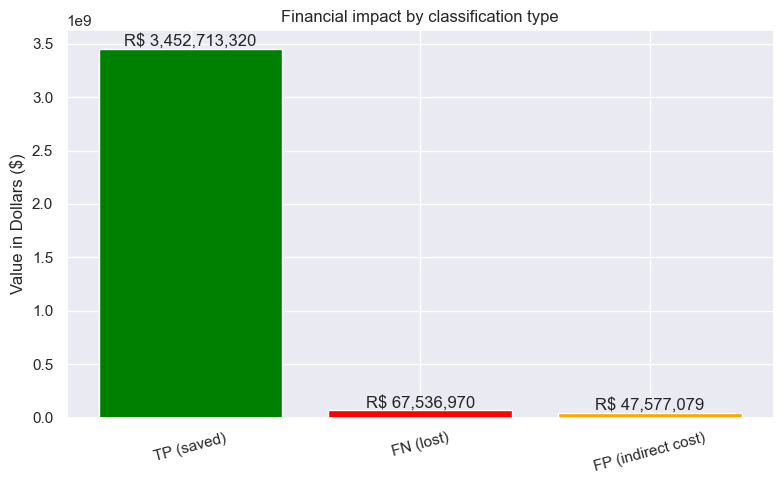

In [108]:
labels = ['TP (saved)', 'FN (lost)', 'FP (indirect cost)']
values = [tp_value, fn_value, fp_value]
colors = ['green', 'red', 'orange']

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=colors)
plt.title("Financial impact by classification type")
plt.ylabel("Value in Dollars ($)")
plt.xticks(rotation=15)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f"R$ {yval:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

Insights:

- **Direct positive impact**: The model was able to detect fraud that, if not intercepted, would have resulted in a loss of more than $3.45 billion. This demonstrates the enormous potential for return on the automated detection system.

- **Residual loss still significant**: Even with the model in operation, approximately $67.5 million in fraudulent transactions were not identified. This indicates room for improvement in the model, especially in Recall, to minimize undetected fraud.

- **Potential cost of false positives**: The interruption of legitimate transactions (false positives) could have impacted approximately $47.5 million. This value should be assessed carefully, as it can represent friction in the user experience or loss of revenue. Secondary verification strategies (such as manual review or additional authentication) can mitigate this cost without impeding legitimate operation.

- **Overall security maintained**: The model allowed the safe execution of approximately $339 billion in legitimate transactions, evidencing that the application did not significantly compromise the normal flow of financial operations.

- **Strategic trade-off**: The model presents a good balance between security and usability, but the business can choose to adjust the decision threshold if it wants to further prioritize detection (Recall) or reduce false alarms (Precision), depending on the risk appetite and the organization's objectives.

- **Justification for adopting the model**: With the estimated billions in avoided losses, even considering the potential costs of false positives, the use of the model is highly justifiable financially — in addition to representing an improvement in operational risk management.